# **Task 1: Term Deposit Subscription Prediction (Bank Marketing)**

###  **Problem Statement**

Banks run marketing campaigns to promote term deposits, but not every customer responds positively. Reaching the wrong customers increases operational cost and reduces campaign efficiency. The challenge is to **identify customers who are more likely to subscribe to a term deposit**, so marketing efforts can be better targeted.

 > This project focuses on building a **classification model** that predicts whether a customer will subscribe to a term deposit based on demographic, financial, and campaign-related information.


###  **Objective**

The main objective of this notebook is to:

* Predict whether a bank customer will subscribe to a term deposit (`yes` or `no`)
* Build and compare multiple classification models
* Evaluate model performance using appropriate metrics
* Explain model predictions using **Explainable AI (XAI)** techniques


### **Dataset Description**

* **Dataset:** Bank Marketing Dataset
* **Source:** UCI Machine Learning Repository
* **Type:** Structured tabular data
* **Target Variable:** `y` (term deposit subscription)

The dataset contains customer information such as age, job, marital status, education, balance, and details of previous marketing campaigns. It includes both **numerical and categorical features**, making feature encoding an important step.


###  **Approach** 
1. **Data Loading & Understanding**

   * Load the dataset
   * Inspect data types, shape, and missing values

2. **Data Cleaning & Preprocessing**

   * Handle categorical features using proper encoding
   * Prepare data for modeling

3. **Exploratory Data Analysis (EDA)**

   * Analyze customer behavior patterns
   * Visualize relationships between features and the target variable

4. **Model Building**

   * Train classification models such as:

     * Logistic Regression
     * Random Forest
     * XGBoost 

5. **Model Evaluation**

   * Evaluate models using:

     * Confusion Matrix
     * F1-Score
     * ROC Curve

6. **Model Explainability (XAI)**

   * Use **SHAP or LIME** to explain at least 5 model predictions
   * Understand how features influence predictions

7. **Conclusion & Insights**

   * Summarize model performance
   * Highlight key insights for customer behavior and marketing strategy


###  **Final Conclusions**

By the end of this notebook, we aim to deliver:

* A reliable prediction model for term deposit subscription
* Clear insights into customer behavior
* Explainable predictions that can support business decision-making



## **Importing Libraries**


In [1]:
# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# model preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.metrics import confusion_matrix, f1_score, roc_curve, auc

# models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier



## **Data Loading and Understanding**

In [2]:
df = pd.read_csv(r'..\dataset\bank_full.csv')

In [3]:
# display first 5 rows
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
rows, cols = df.shape
print(f"The dataset contains {rows} rows and {cols} columns.")

The dataset contains 45211 rows and 17 columns.


In [5]:
# columns in our dataset

df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [7]:
# to check the duplicate rows in the dataset.
print("Number of duplicate rows in the dataset:", df.duplicated().sum())

Number of duplicate rows in the dataset: 0


In [8]:
print("Missing values in the dataset")
print(df.isnull().sum())

Missing values in the dataset
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


No missing values founded.

In [9]:
# check data types
df.dtypes

age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

In [10]:
# Summary statistics for categorical features 
df.describe(include='O')

,job,marital,education,default,housing,loan,contact,month,poutcome,y
count,45211,45211,45211,45211,45211,45211,45211,45211,45211,45211
unique,12,3,4,2,2,2,3,12,4,2
top,blue-collar,married,secondary,no,yes,no,cellular,may,unknown,no
freq,9732,27214,23202,44396,25130,37967,29285,13766,36959,39922


- Most customers did not subscribe to a term deposit.
  
- Many customers have no previous campaign history.
  
- Most customers are blue-collar married and have secondary education

In [11]:
# Summary statistics for numerical features
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## **Data Cleaning and Preprocessing**


Since the dataset is clean with no missing values so it is ready for analysis and modeling without  preprocessing.

## **Exploratory Data Analysis (EDA)**


In [12]:
# checking if the dataset is balanced or not.
df['y'].value_counts()/df.shape[0]

y
no     0.883015
yes    0.116985
Name: count, dtype: float64

The dataset is highly imbalanced with only about 12% of customers subscribing to a term deposit.

In [13]:
# separate categorical and numerical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()


print(f"Categorical Columns {len(categorical_cols)}: {categorical_cols}")
print(f"Numerical Columns {len(numerical_cols)}: {numerical_cols}")



Categorical Columns 10: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']
Numerical Columns 7: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


#### **Age**

In [14]:
df["age"].describe()

count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

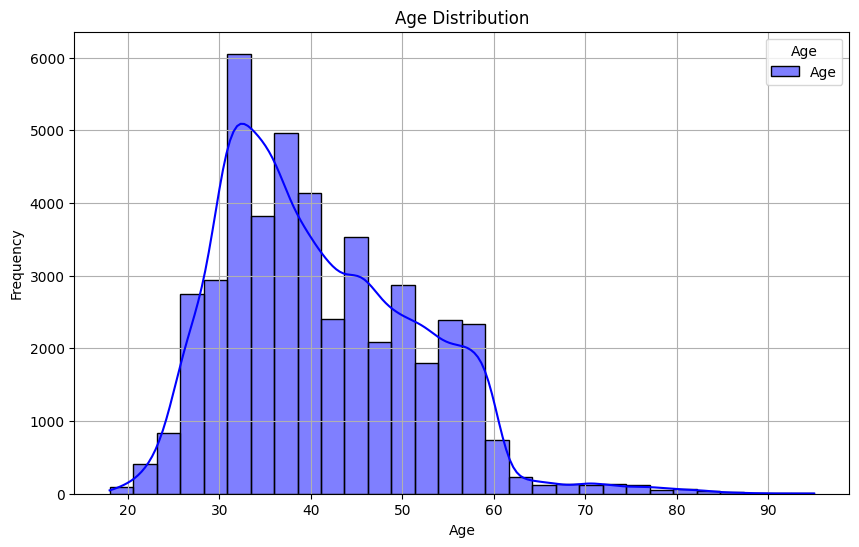

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df["age"],kde=True,bins=30,label="Age",color='blue')
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend(loc="best",title="Age")
plt.title("Age Distribution")
plt.grid(True)
plt.show()

- Most people age group are around 30–45, slight right skew with fewer older clients.
- Long tail beyond 60 indicates limited seniors.

  #### **Balance**


In [16]:
df['balance'].describe()

count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

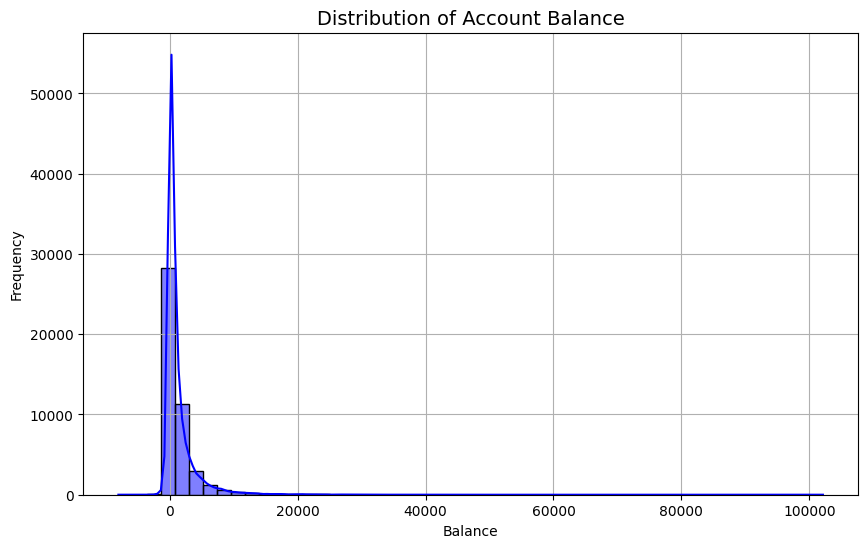

In [17]:

plt.figure(figsize=(10, 6))


sns.histplot(df['balance'], bins=50, kde=True, color='blue')
plt.title('Distribution of Account Balance', fontsize=14)
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

- Highly right-skewed and most balances near zero or modest positive.
- Few extreme high balances they might be the outliers.


  #### **Day**

In [18]:
dayCounts = df['day'].value_counts()
dayCounts.head(10)

day
20    2752
18    2308
21    2026
17    1939
6     1932
5     1910
14    1848
8     1842
28    1830
7     1817
Name: count, dtype: int64

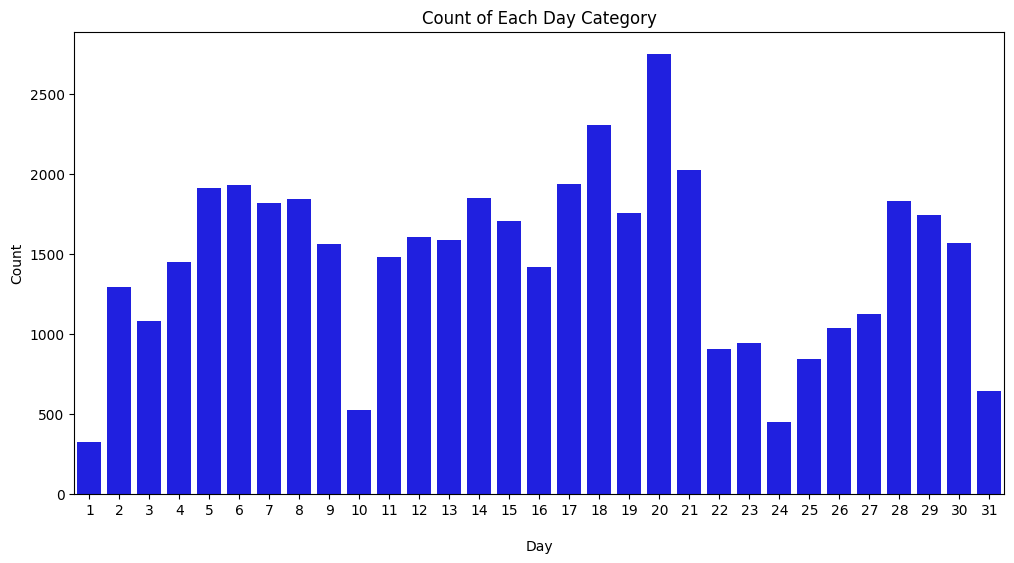

In [19]:
plt.figure(figsize=(12, 6))
sns.barplot(x=dayCounts.index, y=dayCounts.values, color='blue')
plt.title('Count of Each Day Category')
plt.xlabel('\nDay')
plt.ylabel('Count')
plt.show()

- Calls are not uniform and peaks around days 18–21.
- Dips are around day 10 and mid late 20s.


  #### **Duration**

In [20]:
durationCounts = df['duration'].value_counts()
durationCounts.head(10)

duration
124    188
90     184
89     177
104    175
114    175
122    175
136    174
112    174
139    174
121    173
Name: count, dtype: int64

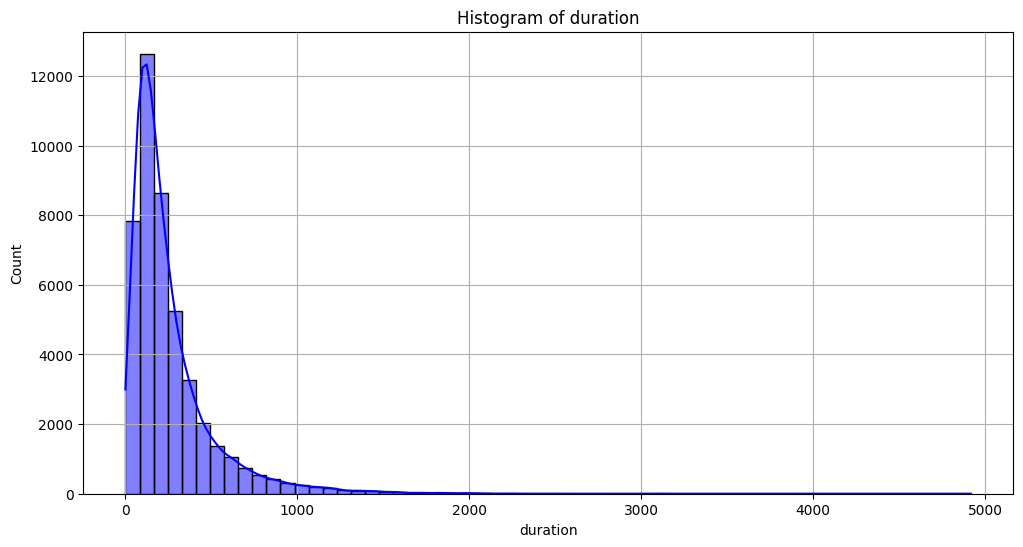

In [ ]:
plt.figure(figsize=(12,6))
ax = sns.histplot(df['duration'],bins=60 ,kde=True,color='blue')
plt.title('Histogram of duration')
plt.xlabel('duration')
plt.grid(True)
plt.show()

- Most people have short calls and a few have very long ones.

#### **Campaign**

In [22]:
campaingnCounts = df['campaign'].value_counts()
campaingnCounts.head(10)

campaign
1     17544
2     12505
3      5521
4      3522
5      1764
6      1291
7       735
8       540
9       327
10      266
Name: count, dtype: int64

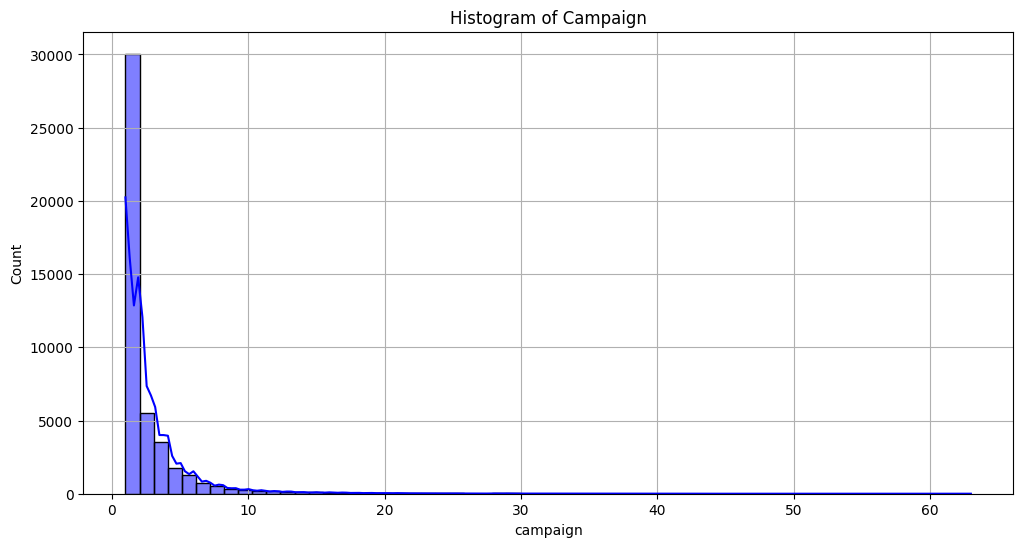

In [23]:
plt.figure(figsize=(12,6))
ax = sns.histplot(df['campaign'],bins=60 ,kde=True,color='blue')
plt.title('Histogram of Campaign')
plt.xlabel('campaign')
plt.grid(True)
plt.show()

- Most people were contacted 1 to 3 times and with only a few contacted more than 10 times.

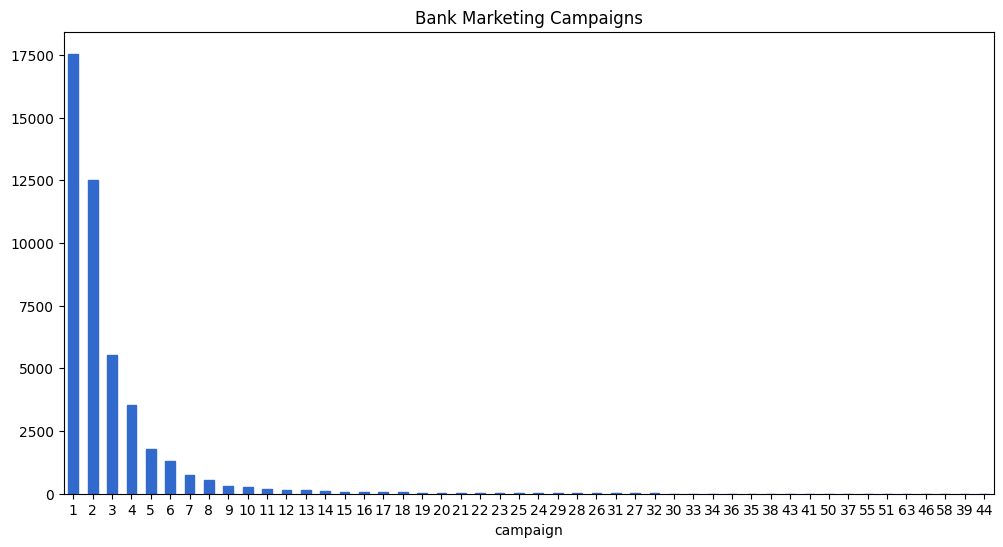

In [24]:
plt.figure(figsize=(12, 6))
campaingnCounts.plot(
    kind='bar',
    color='#3169CC',
    edgecolor='#3169CC',
    title='Bank Marketing Campaigns'
)
plt.xticks(rotation=0)
plt.show()



- Most people were contacted once and more contacts help less.


  #### **pdays**

In [25]:
df['pdays'].describe()

count    45211.000000
mean        40.197828
std        100.128746
min         -1.000000
25%         -1.000000
50%         -1.000000
75%         -1.000000
max        871.000000
Name: pdays, dtype: float64

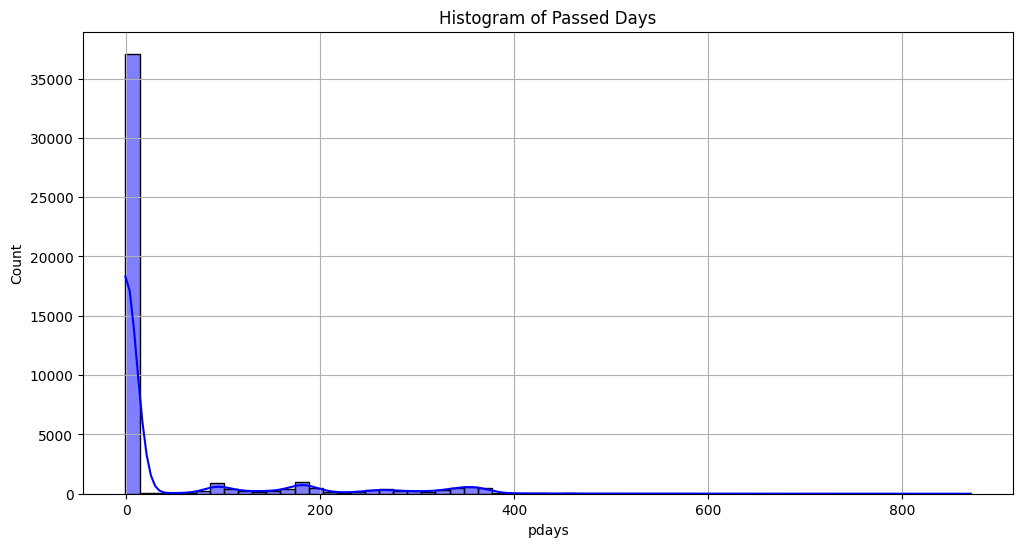

In [26]:
plt.figure(figsize=(12,6))
ax = sns.histplot(df['pdays'],bins=60 ,kde=True,color='blue')
plt.title('Histogram of Passed Days')
plt.xlabel('pdays')
plt.grid(True)
plt.show()

In [27]:
new_pdays = df[df['pdays'] != -1]
new_pdays['pdays'].describe()

count    8257.000000
mean      224.577692
std       115.344035
min         1.000000
25%       133.000000
50%       194.000000
75%       327.000000
max       871.000000
Name: pdays, dtype: float64

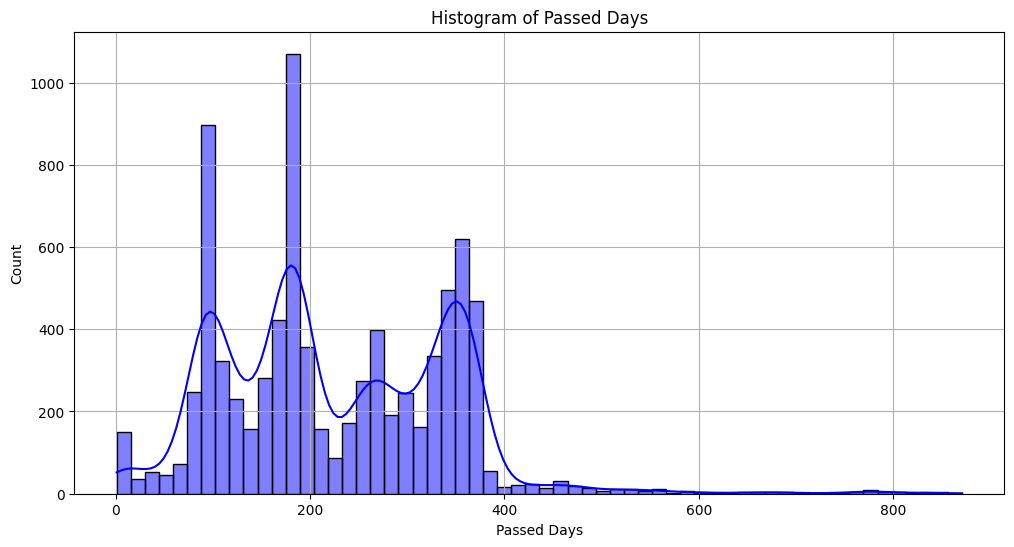

In [28]:
plt.figure(figsize=(12,6))
ax = sns.histplot(new_pdays['pdays'],bins=60 ,kde=True,color='blue')
plt.title('Histogram of Passed Days')
plt.xlabel('Passed Days')
plt.grid(True)
plt.show()


  #### **Previous**

In [29]:
df['previous'].describe()

count    45211.000000
mean         0.580323
std          2.303441
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        275.000000
Name: previous, dtype: float64

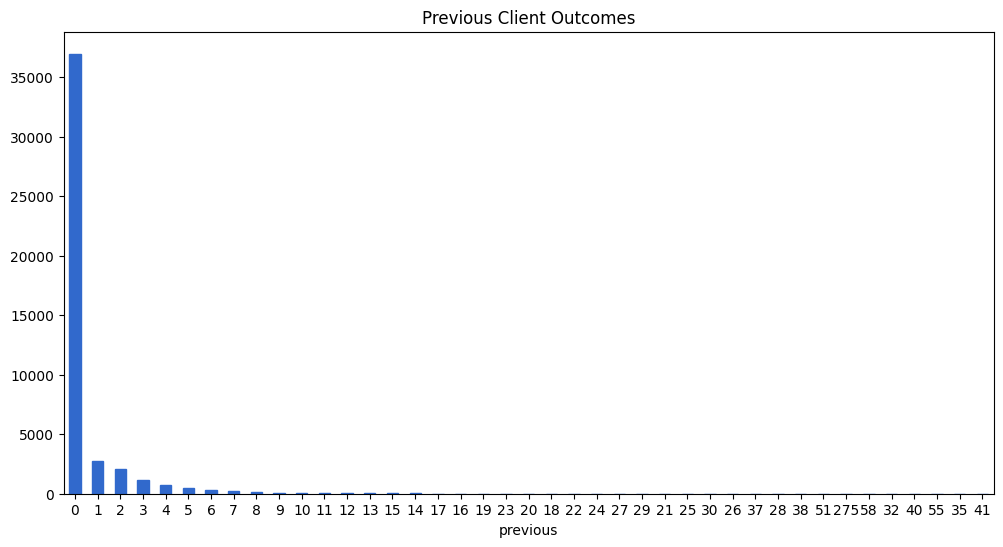

In [30]:
plt.figure(figsize=(12, 6))
poutcomeCounts = df['previous'].value_counts()

poutcomeCounts.plot(
    kind='bar',
    color='#3169CC',
    edgecolor='#3169CC',
    title='Previous Client Outcomes'
)

plt.xticks(rotation=0)
plt.show()

- Most people had 0–1 prior contacts, and high counts are rare.


#### **Job**

In [31]:
df["job"].value_counts()

job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64

In [32]:
# replace unknown with others

df['job'] = df['job'].replace('unknown', 'others')
df["job"].value_counts()


job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
others            288
Name: count, dtype: int64

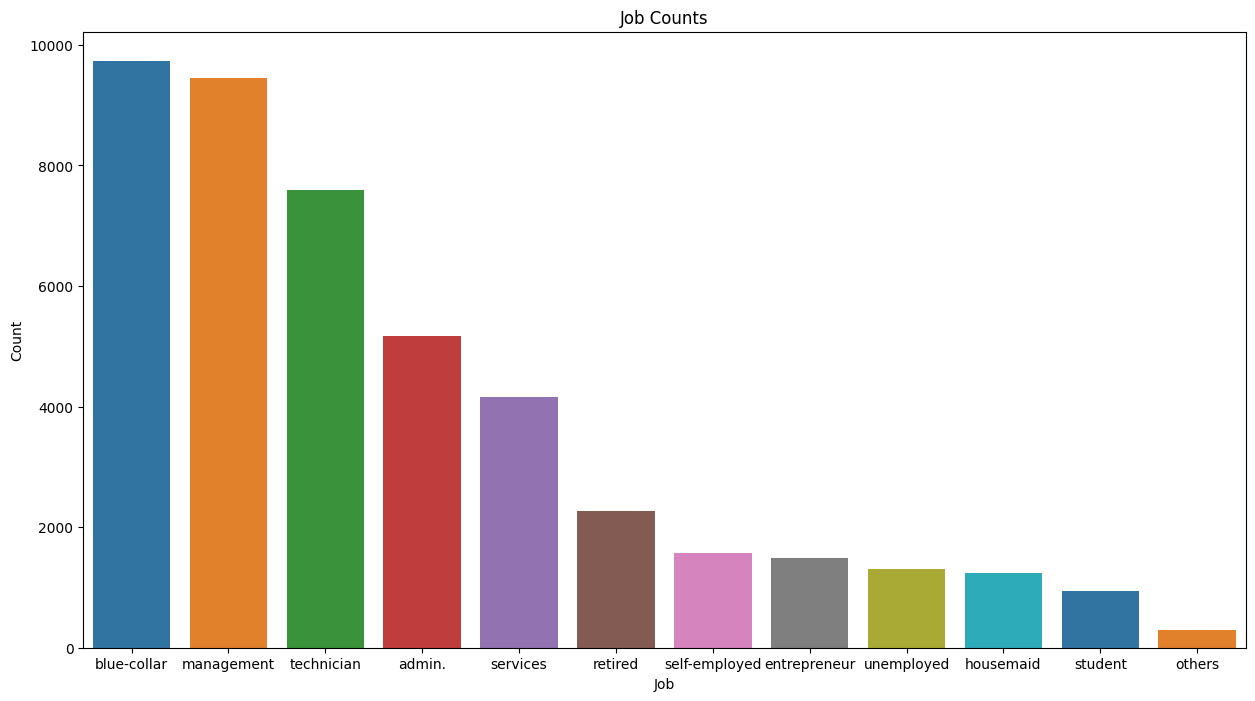

In [33]:
job_count = df["job"].value_counts()
plt.figure(figsize=(15,8))
sns.barplot(x=job_count.index, y=job_count.values, palette='tab10')
plt.xlabel('Job')
plt.xticks()
plt.ylabel('Count')
plt.title('Job Counts')
plt.show()

- Most people are in blue-collar management technician admin or services
- Few are students unemployed housemaids or others

#### **Martial**

In [34]:
maritalCounts = df["marital"].value_counts()
maritalCounts

marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

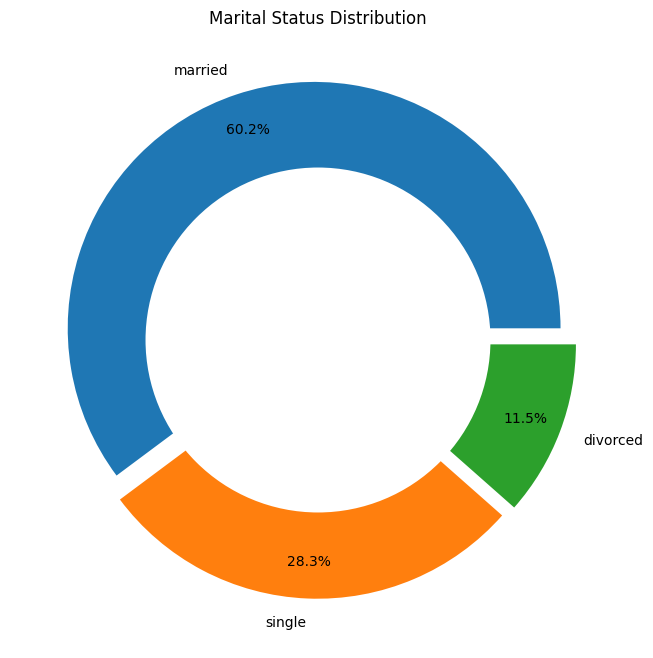

In [35]:

# pie chart
num_categories = len(maritalCounts)

colors = plt.get_cmap('tab10').colors[:num_categories]

explode = [0.05] * num_categories

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    maritalCounts,
    colors=colors,
    labels=maritalCounts.index,
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add title
plt.title('Marital Status Distribution')

plt.show()

- Most people are married and some are single where few are divorced.

#### **Education**



In [36]:
df['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64

In [37]:
df['education'] = df['education'].replace('unknown', 'others')
df['education'].value_counts()

education
secondary    23202
tertiary     13301
primary       6851
others        1857
Name: count, dtype: int64

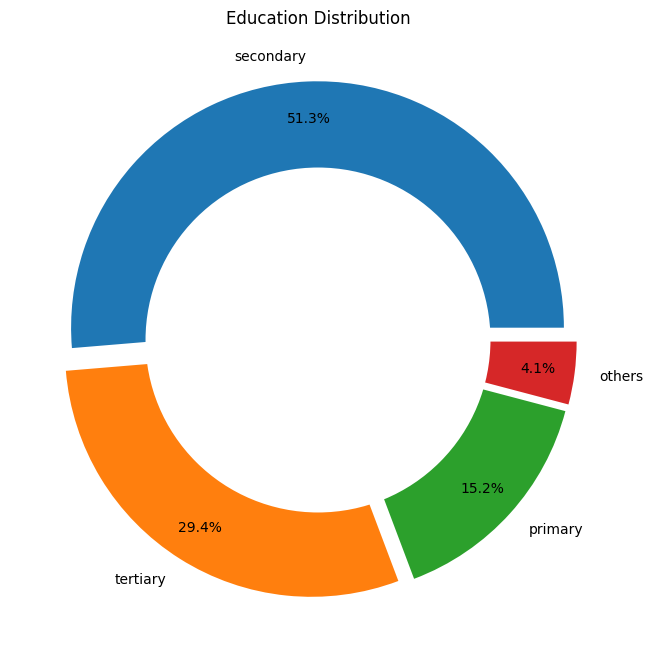

In [38]:
eduCounts = df['education'].value_counts()
num_categories = len(eduCounts)

colors = plt.get_cmap('tab10').colors[:num_categories]


explode = [0.05] * num_categories

# pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    eduCounts,
    colors=colors,
    labels=eduCounts.index,  
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# add title
plt.title('Education Distribution')

plt.show()

- Most people have secondary education some have tertiary fewer have primary and the rest are very small.


  #### **Month**

In [39]:
df['month'].value_counts()

month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

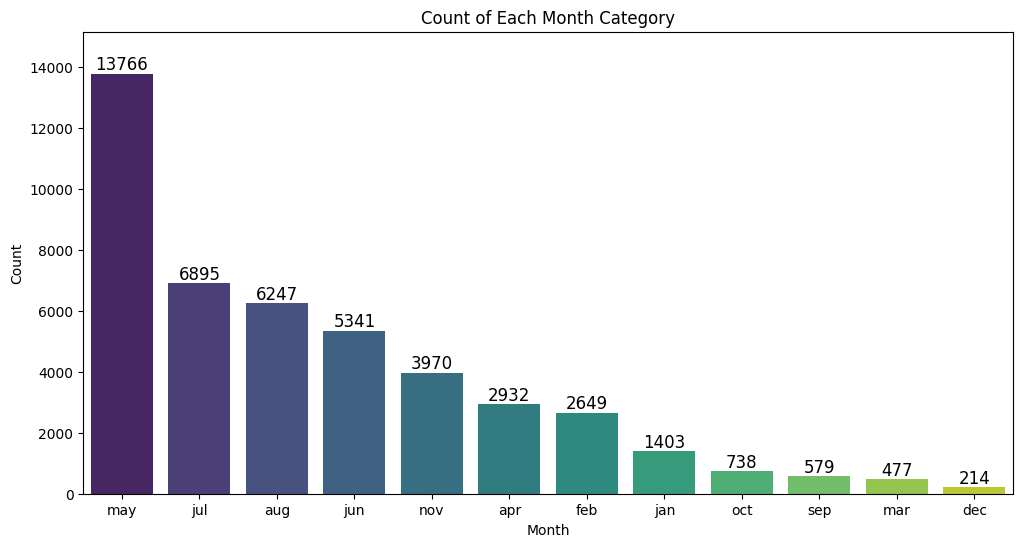

In [40]:
mCounts = df['month'].value_counts()

plt.figure(figsize=(12, 6))
barplot = sns.barplot(x=mCounts.index, y=mCounts.values, palette='viridis')

for i, count in enumerate(mCounts.values):
    barplot.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=12)

plt.ylim(0, max(mCounts.values) * 1.1)  

plt.title('Count of Each Month Category')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

- Most activity happens in May then June to August least in winter and early spring showing seasonal patterns.


  #### **Contacts**

In [41]:
df['contact'].value_counts()

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64

In [42]:
df['contact'] = df['contact'].replace('unknown', 'others')
df['contact'].value_counts()

contact
cellular     29285
others       13020
telephone     2906
Name: count, dtype: int64

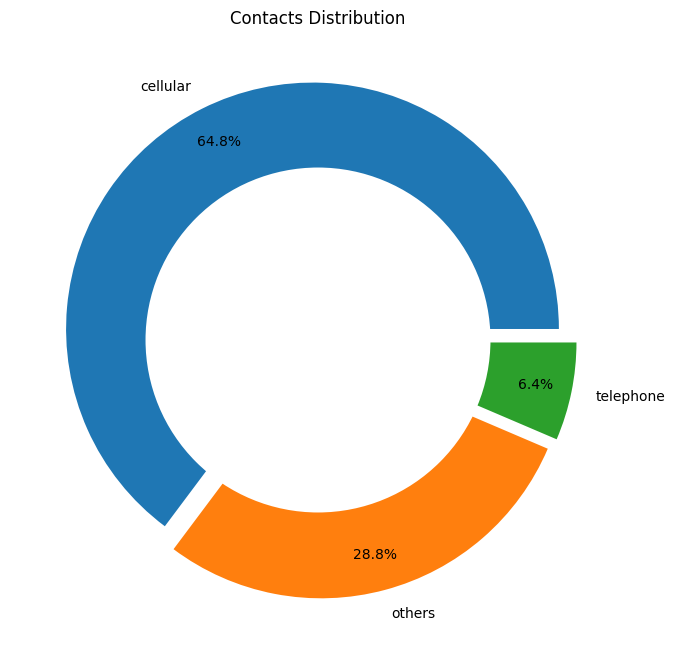

In [43]:
contactCounts = df['contact'].value_counts()
num_categories = len(contactCounts)

# Colors from tab10 colormap
colors = plt.get_cmap('tab10').colors[:num_categories]

# Explode values
explode = [0.05] * num_categories

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    contactCounts,
    colors=colors,
    labels=contactCounts.index,  
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)

# Draw center circle to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add title
plt.title('Contacts Distribution')

plt.show()

- Most use cellular few use telephone and the rest use other types.


  #### **Loan Housing & Default**

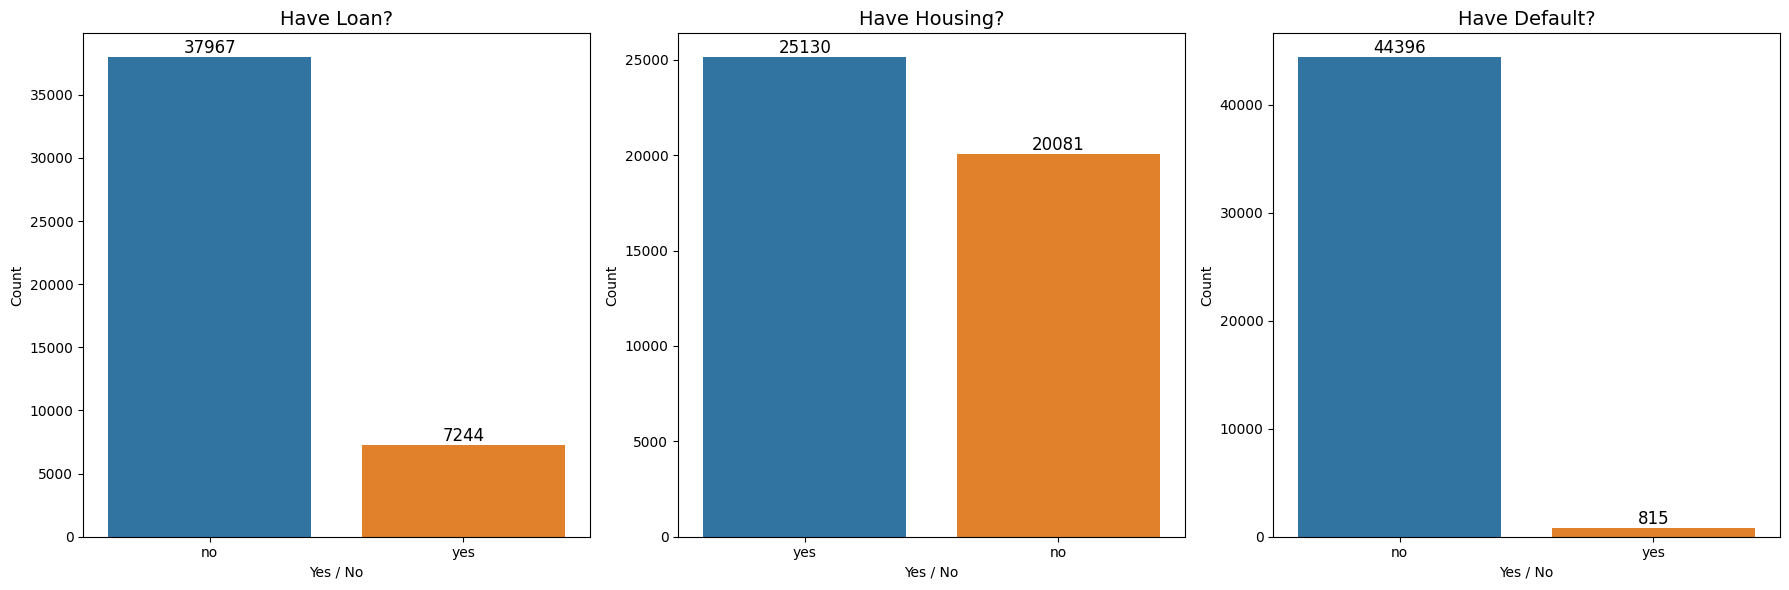

In [44]:
# columns to plot
columns = ['loan','housing', 'default']

plt.figure(figsize=(18, 6)) 

for i, col in enumerate(columns, start=1):
    plt.subplot(1, 3, i) 
    counts = df[col].value_counts()
    sns.barplot(x=counts.index, y=counts.values, palette='tab10')
    
    for j, count in enumerate(counts.values):
        plt.text(j, count + 0.5, str(count), ha='center', va='bottom', fontsize=12)
    
    plt.title(f'Have {col.capitalize()}?', fontsize=14)
    plt.xlabel('Yes / No')
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

- Most don’t have personal loans.
- Housing loans are slightly more common. 
- Credit defaults are rare.


  #### **Poutcome**

In [45]:
poutcomeCounts = df['poutcome'].value_counts()
poutcomeCounts

poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64

In [46]:
df['poutcome'] = df['poutcome'].replace({'unknown': 'other'})
df['poutcome'].value_counts()


poutcome
other      38799
failure     4901
success     1511
Name: count, dtype: int64

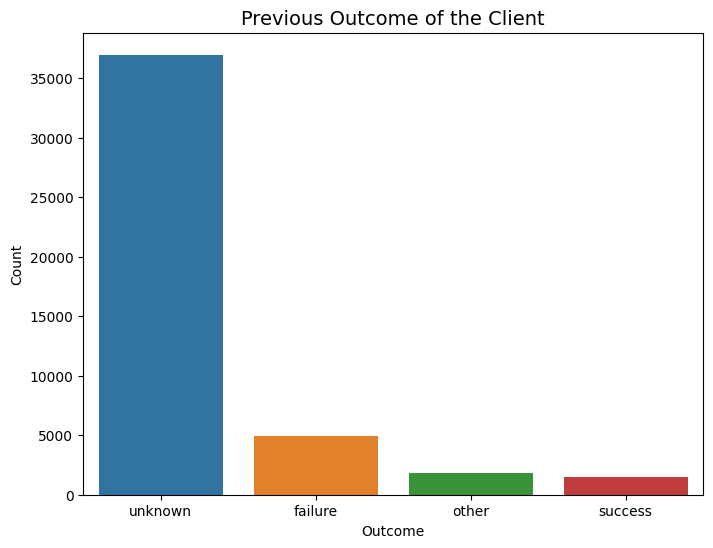

In [47]:

plt.figure(figsize=(8, 6))
sns.barplot(x=poutcomeCounts.index, y=poutcomeCounts.values, palette='tab10')

plt.title('Previous Outcome of the Client', fontsize=14)
plt.xlabel('Outcome')
plt.ylabel('Count')

plt.show()



- Most outcomes are `Other` and failures are more common than successes which are few.


  #### **Y**

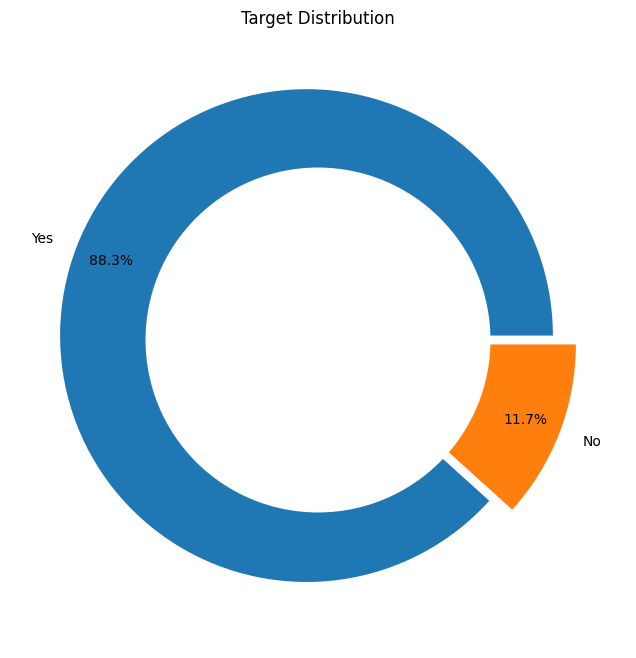

In [48]:
targetCounts = df['y'].value_counts()
num_categories = len(targetCounts)

# Colors from tab10 colormap
colors = plt.get_cmap('tab10').colors[:num_categories]

# Explode values
explode = [0.05] * num_categories

# Pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    targetCounts,
    colors=colors,
    labels=['Yes', 'No'],  # force labels as Yes/No
    autopct='%1.1f%%',
    pctdistance=0.85,
    explode=explode
)

# Draw center circle to make it a donut chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Add title
plt.title('Target Distribution')

plt.show()

- About 88% are yes and 12% are no the data is very imbalanced.

<Figure size 1000x800 with 0 Axes>

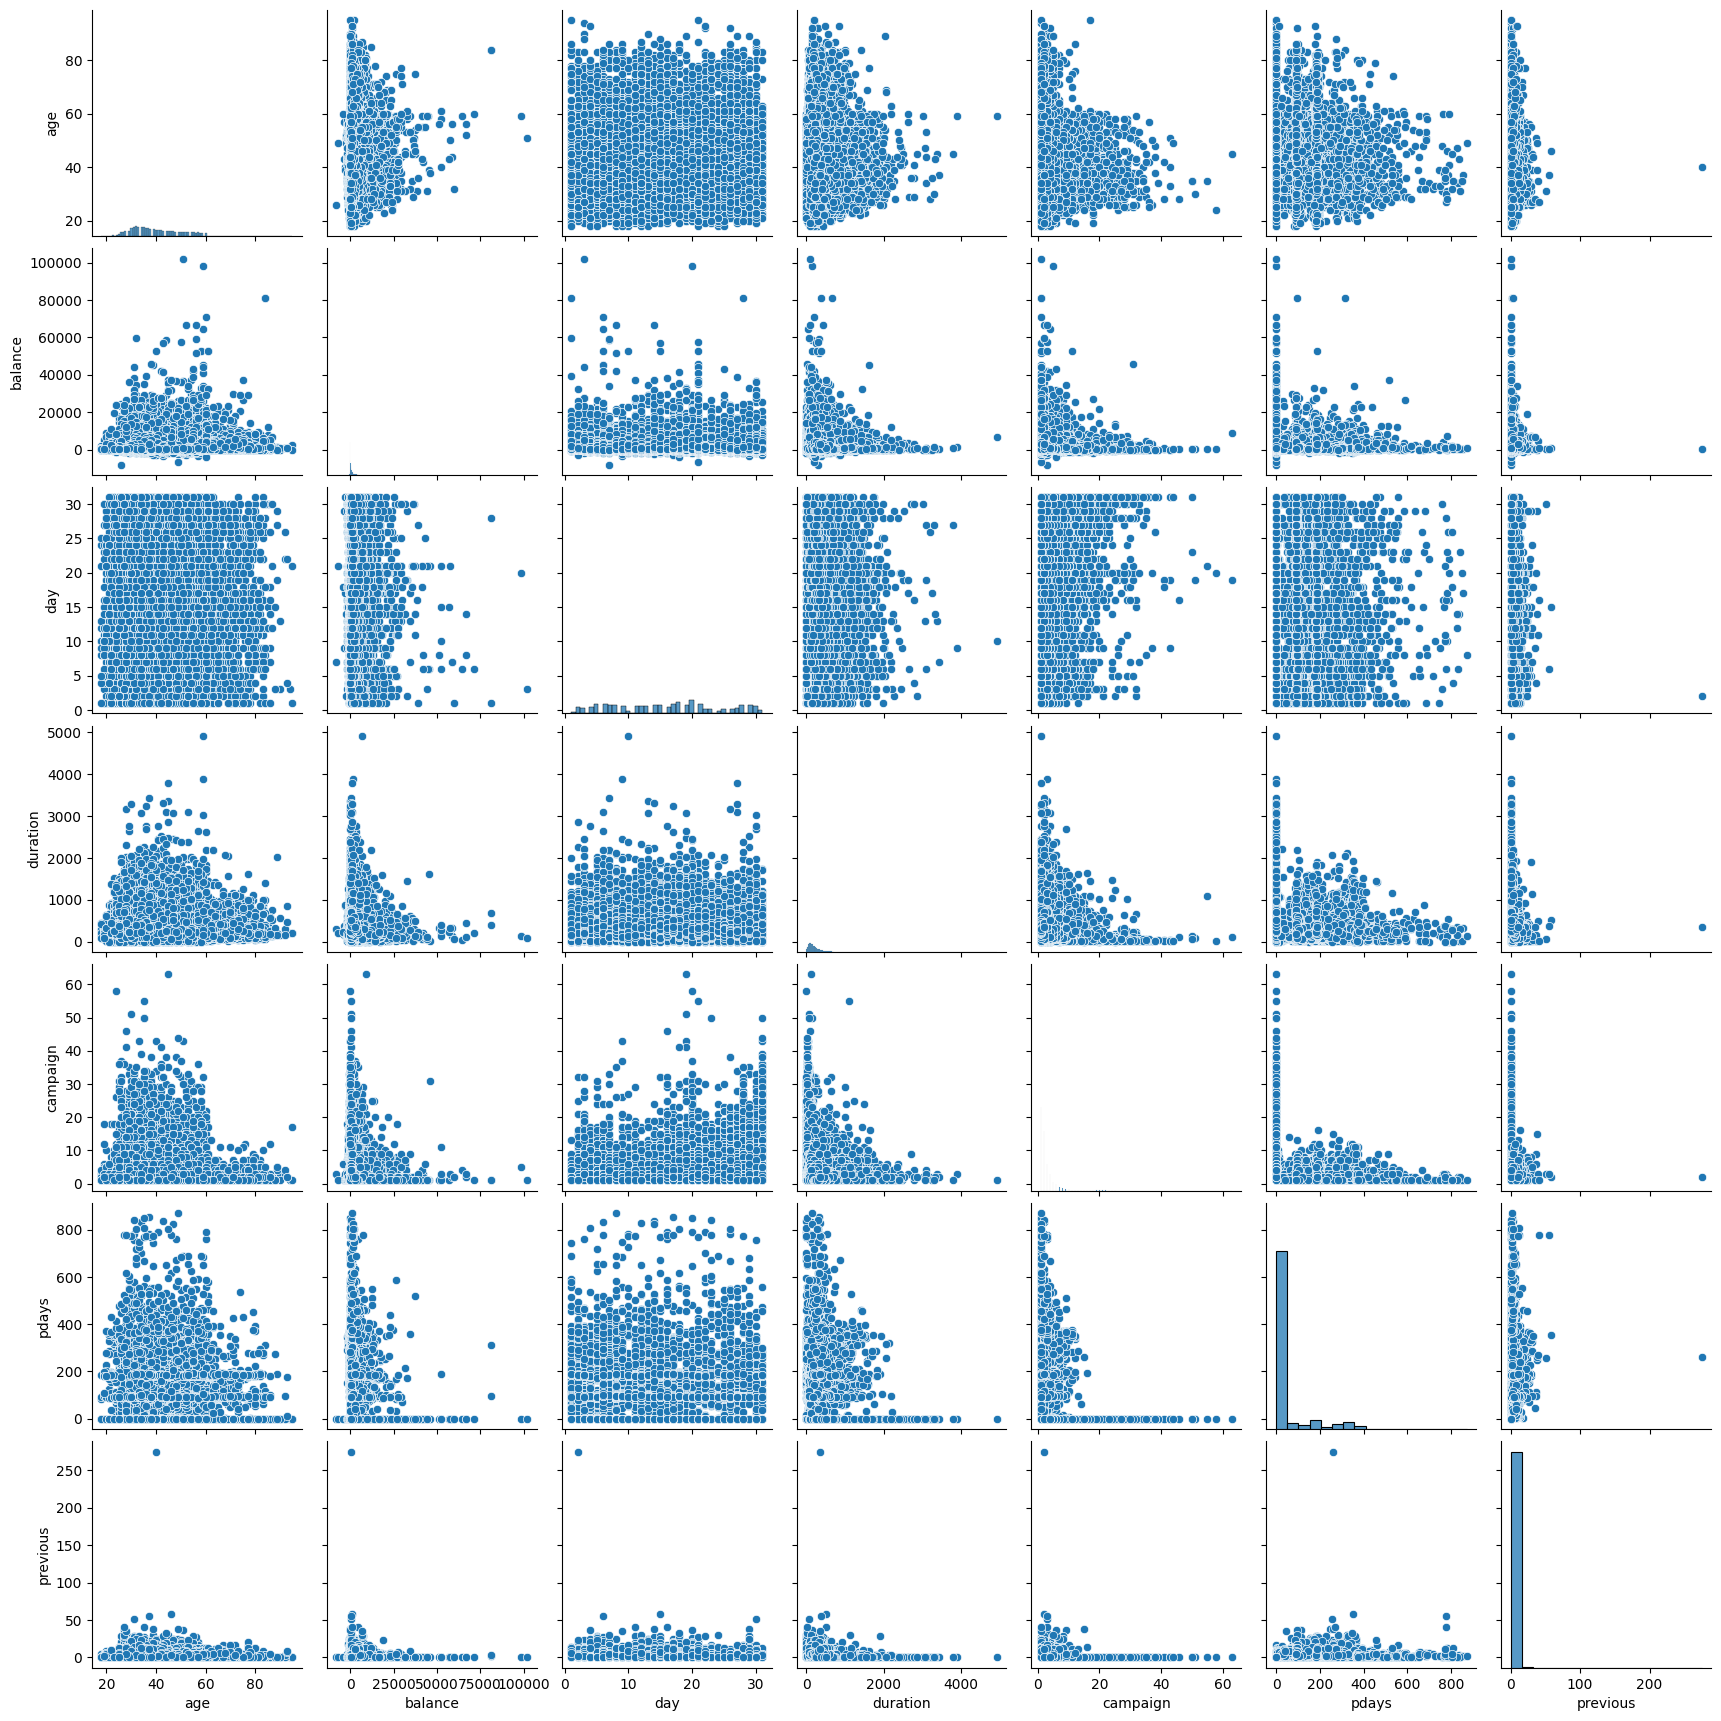

In [49]:
# Pairplot for all numerical features.
plt.figure(figsize = (10,8))
sns.pairplot(data =df[numerical_cols])
plt.show()

##### **Preparing Data for Modeling**

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score,classification_report
from IPython.display import display
import shap




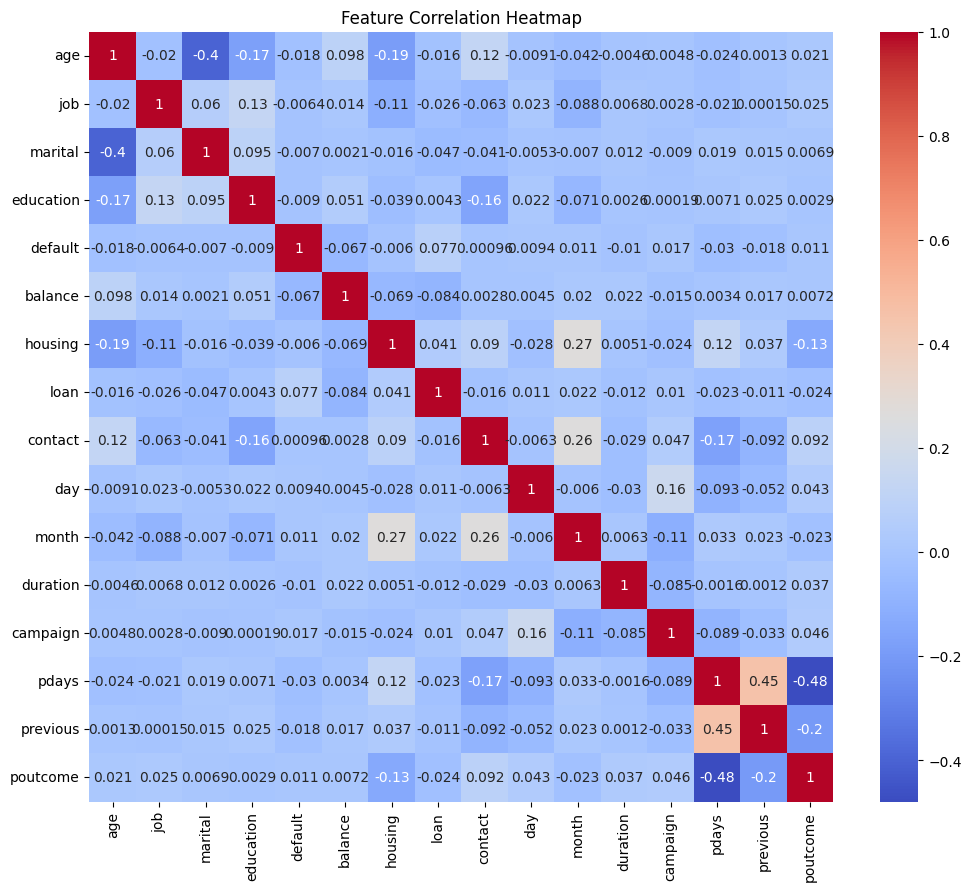

In [51]:

# separate features and target
encoder = LabelEncoder()

X = df.drop('y', axis=1).copy()
y = encoder.fit_transform(df['y'])

for column in X.columns:
    if X[column].dtype == 'object':
        X[column] = encoder.fit_transform(X[column])


corr = X.corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [52]:
Q1 = X['balance'].quantile(0.25)
Q3 = X['balance'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

X['balance'] = X['balance'].clip(lower, upper)





# yeo–johnson transform
pt = PowerTransformer(method='yeo-johnson')

X[['balance_yj', 'duration_yj']] = pt.fit_transform(
    X[['balance', 'duration']]
)


X.drop(['balance', 'duration'], axis=1, inplace=True)


In [53]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


# pipeline for scaling numerical
numerical_cols = [
    'age', 'balance_yj', 'duration_yj',
    'day', 'campaign', 'pdays', 'previous'
]

categorical_cols = [col for col in X_train.columns if col not in numerical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', 'passthrough', categorical_cols)
    ]
)


X_train shape: (36168, 16)
X_test shape: (9043, 16)
y_train shape: (36168,)
y_test shape: (9043,)


## **Model Building**


In [54]:
# logistic regression
lr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced'))
])

# random forest
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=600, random_state=42, class_weight='balanced'))
])

# gradient boosting
gb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=600, random_state=42))
])

# xgboost
xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(
        n_estimators=200, use_label_encoder=False, eval_metric='logloss',
        scale_pos_weight=(y_train==0).sum() / (y_train==1).sum()
    ))
])

models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model,
    'XGBoost': xgb_model
}


In [55]:
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)


Training Logistic Regression...
Training Random Forest...
Training Gradient Boosting...
Training XGBoost...


## **Model Evaluation**



=== Logistic Regression ===


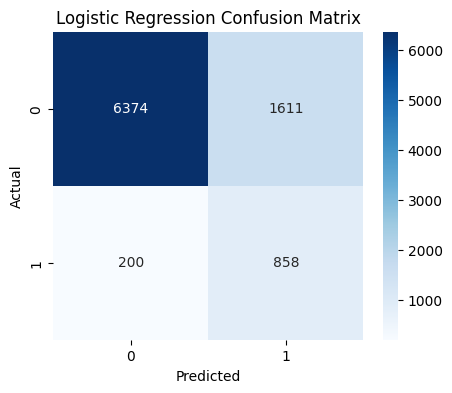

              precision    recall  f1-score   support

           0       0.97      0.80      0.88      7985
           1       0.35      0.81      0.49      1058

    accuracy                           0.80      9043
   macro avg       0.66      0.80      0.68      9043
weighted avg       0.90      0.80      0.83      9043



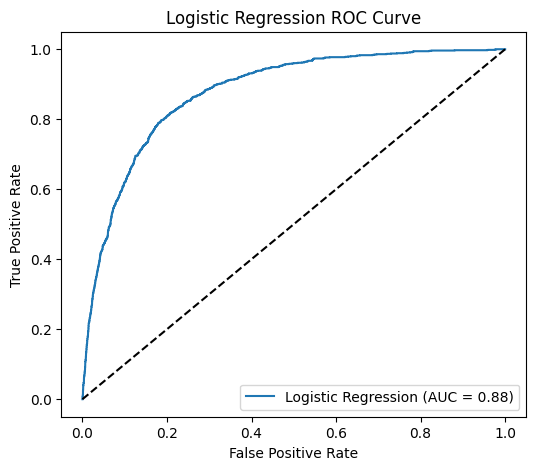


=== Random Forest ===


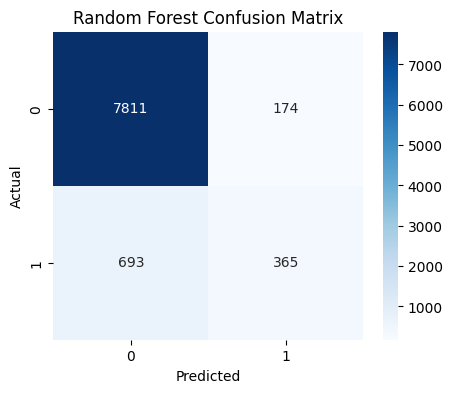

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.68      0.34      0.46      1058

    accuracy                           0.90      9043
   macro avg       0.80      0.66      0.70      9043
weighted avg       0.89      0.90      0.89      9043



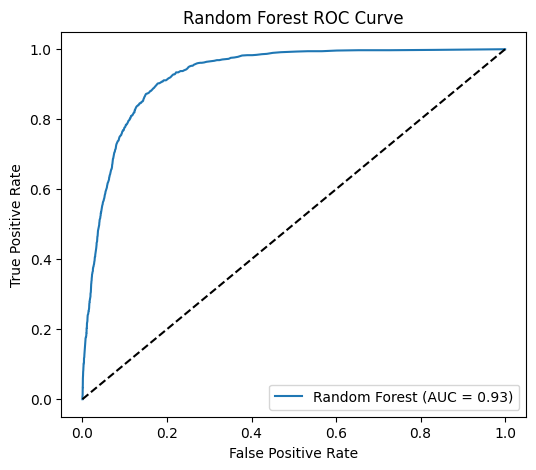


=== Gradient Boosting ===


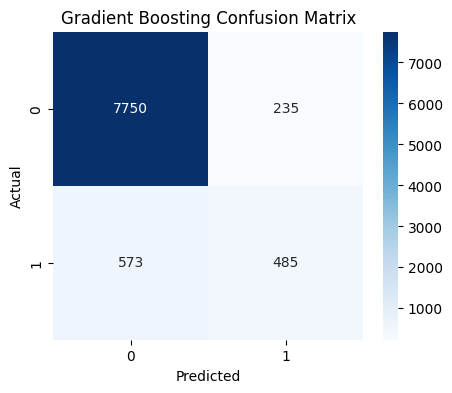

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7985
           1       0.67      0.46      0.55      1058

    accuracy                           0.91      9043
   macro avg       0.80      0.71      0.75      9043
weighted avg       0.90      0.91      0.90      9043



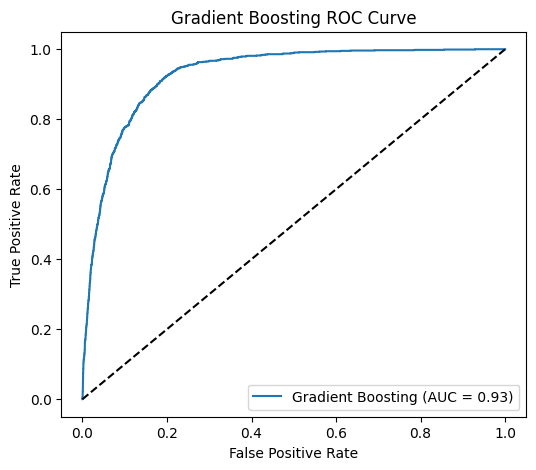


=== XGBoost ===


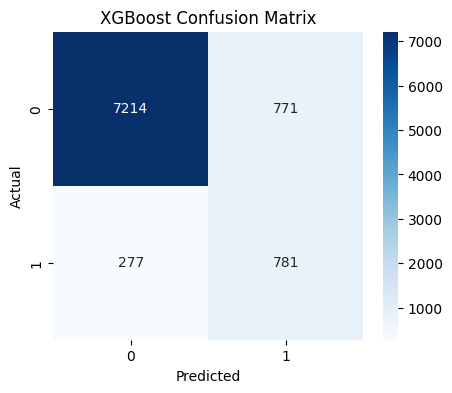

              precision    recall  f1-score   support

           0       0.96      0.90      0.93      7985
           1       0.50      0.74      0.60      1058

    accuracy                           0.88      9043
   macro avg       0.73      0.82      0.77      9043
weighted avg       0.91      0.88      0.89      9043



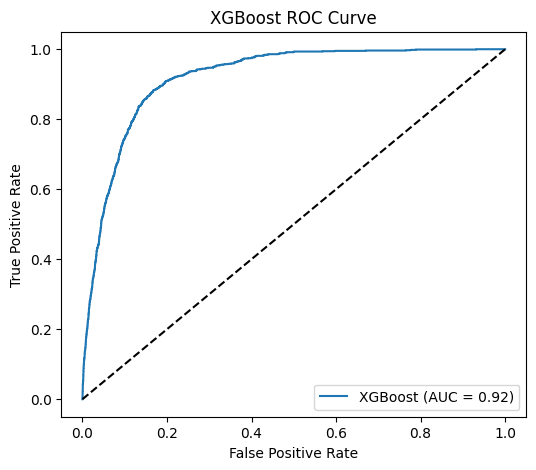

,Model,F1-Score,Precision,Recall,ROC-AUC
0,XGBoost,0.598467,0.503222,0.738185,0.919436
1,Gradient Boosting,0.545557,0.673611,0.458412,0.929114
2,Logistic Regression,0.486532,0.347509,0.810964,0.877538
3,Random Forest,0.457107,0.677180,0.344991,0.927307


In [56]:
# to store metrics
metrics_list = []

for name, model in models.items():
    print(f"\n=== {name} ===")
    
    # predictions
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    
    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()
    
    # classification report
    print(classification_report(y_test, y_pred))
    
    # roc curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.2f})')
    plt.plot([0,1],[0,1],'k--')
    plt.title(f"{name} ROC Curve")
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend()
    plt.show()
    
    
    # store metrics 
    metrics_list.append({
        'Model': name,
        'F1-Score': f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'ROC-AUC': auc
    })

# convert metrics to df and sort by f1-score
metrics_df = pd.DataFrame(metrics_list)
metrics_df = metrics_df.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)


metrics_df

In [57]:
best_model_name = metrics_df.loc[0, 'Model']
best_model = models[best_model_name]
best_model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


XGBoost was chosen as the final model because it most effectively identifies customers likely to subscribe to a term deposit
maximizing campaign reach while reducing wasted marketing efforts in an imbalanced customer base.

## **Model Explainability (XAI)**


In [58]:
# extract preprocessor and classifier from pipeline
preprocessor = best_model.named_steps['preprocessor']
classifier = best_model.named_steps['classifier']

# transform test data
X_test_transformed = preprocessor.transform(X_test)

# get feature names after preprocessing
num_features = preprocessor.transformers_[0][2]  
cat_features = preprocessor.transformers_[1][2]  
feature_names = num_features + cat_features

shap.initjs()

explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_transformed)



In [ ]:
y_proba = classifier.predict_proba(X_test_transformed)[:, 1]




In [60]:
top5_indices = np.argsort(y_proba)[-5:]

X_top5 = X_test_transformed[top5_indices]

shap_values_top5 = explainer.shap_values(X_top5)


In [62]:

# loop over the 5 predictions
for i, idx in enumerate(top5_indices):
    print(f"\n Force plot for prediction {i+1} (index {idx}):")
    
    # Create the force plot
    force_plot = shap.force_plot(
        explainer.expected_value, 
        shap_values_top5[i], 
        X_top5[i], 
        feature_names=feature_names
    )
    
    display(force_plot)



 Force plot for prediction 1 (index 2353):



 Force plot for prediction 2 (index 6591):



 Force plot for prediction 3 (index 4951):



 Force plot for prediction 4 (index 7422):



 Force plot for prediction 5 (index 2399):



 Waterfall plot for prediction 1


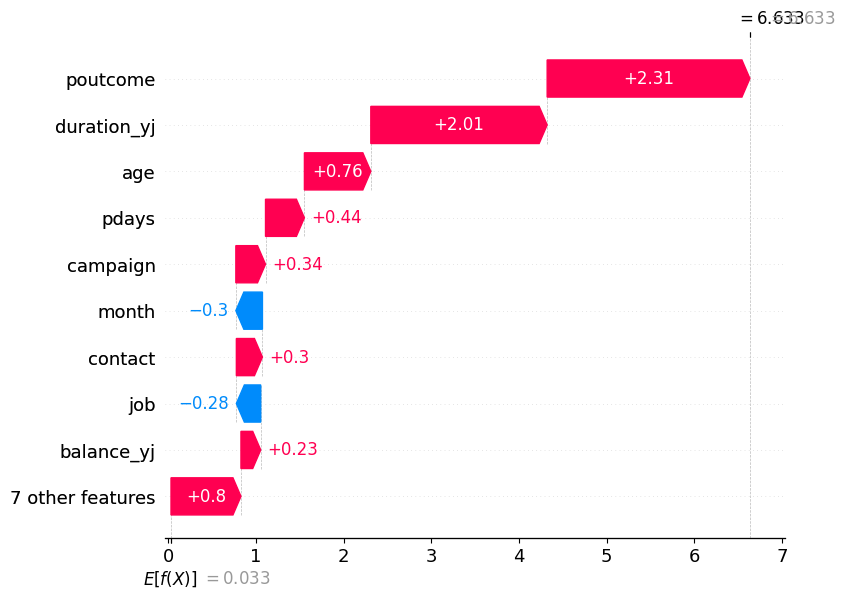


 Waterfall plot for prediction 2


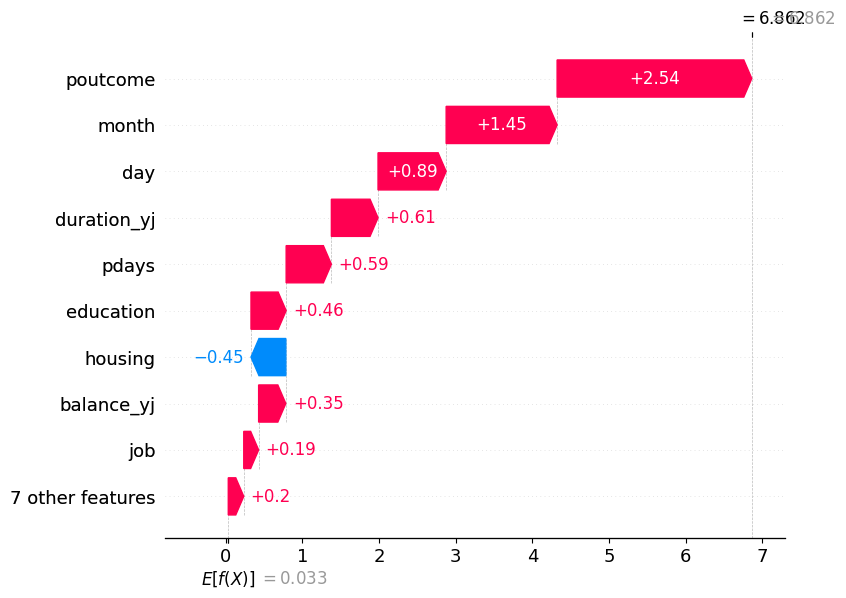


 Waterfall plot for prediction 3


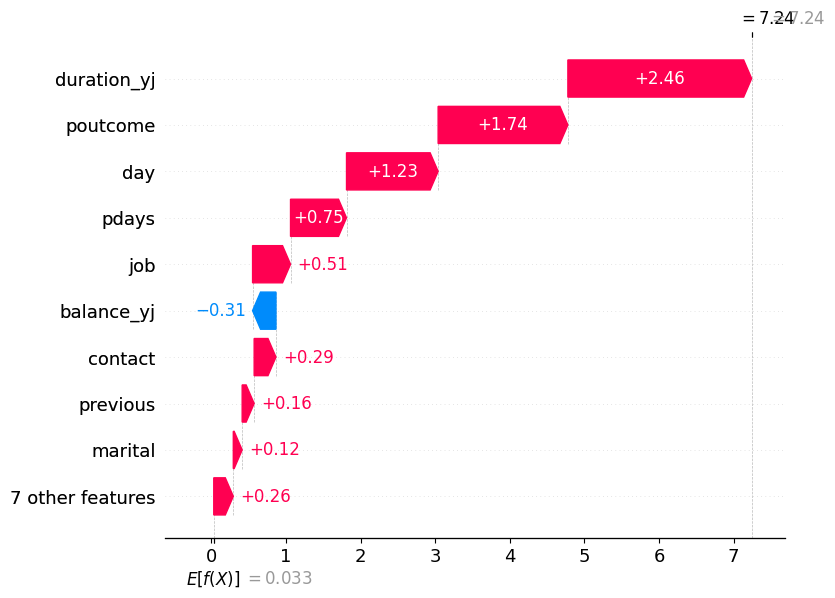


 Waterfall plot for prediction 4


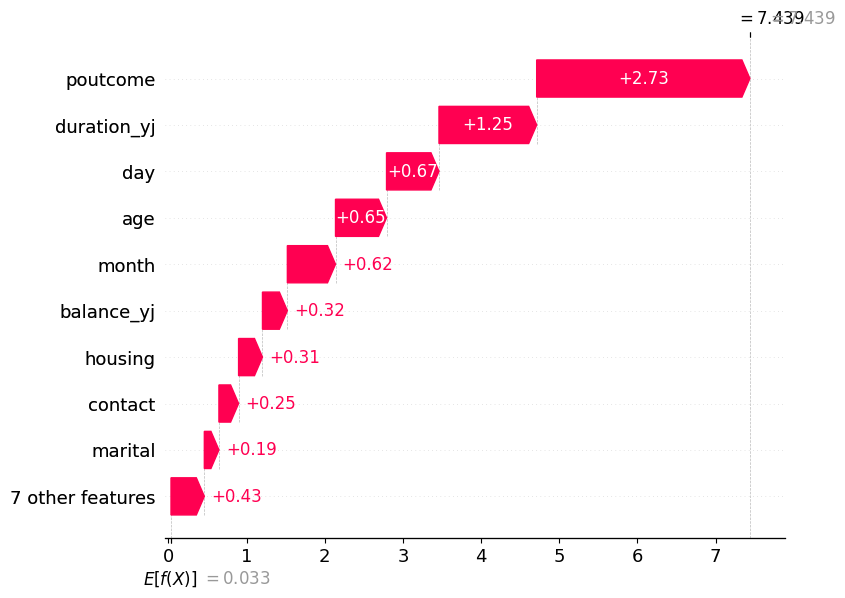


 Waterfall plot for prediction 5


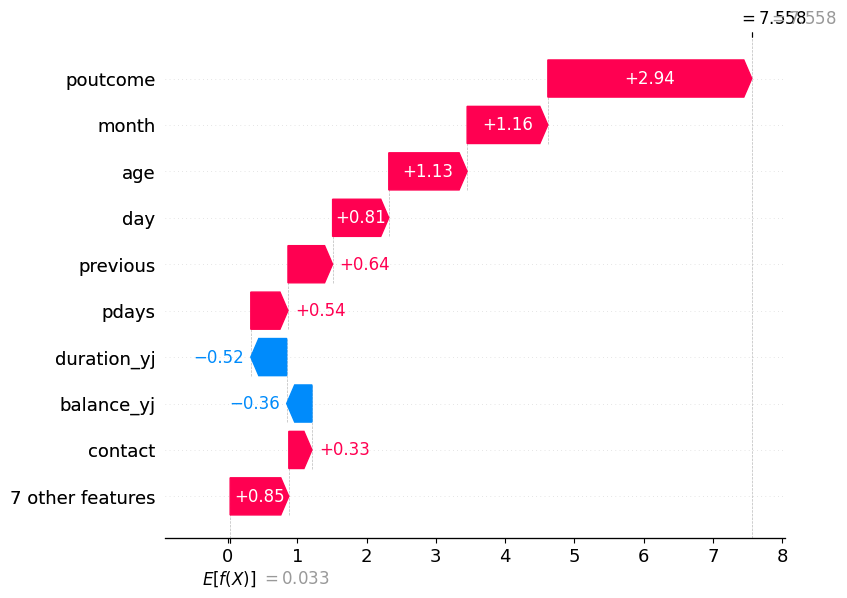

In [63]:
for i in range(5):
    print(f"\n Waterfall plot for prediction {i+1}")
    shap.plots._waterfall.waterfall_legacy(
        explainer.expected_value, 
        shap_values_top5[i], 
        feature_names=feature_names
    )



Feature importance bar plot for prediction 1 (index 2353):


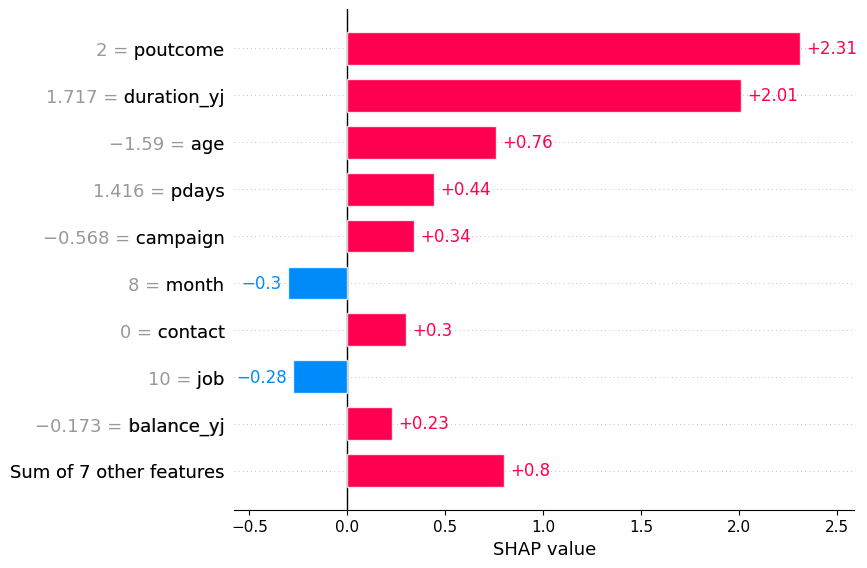


Feature importance bar plot for prediction 2 (index 6591):


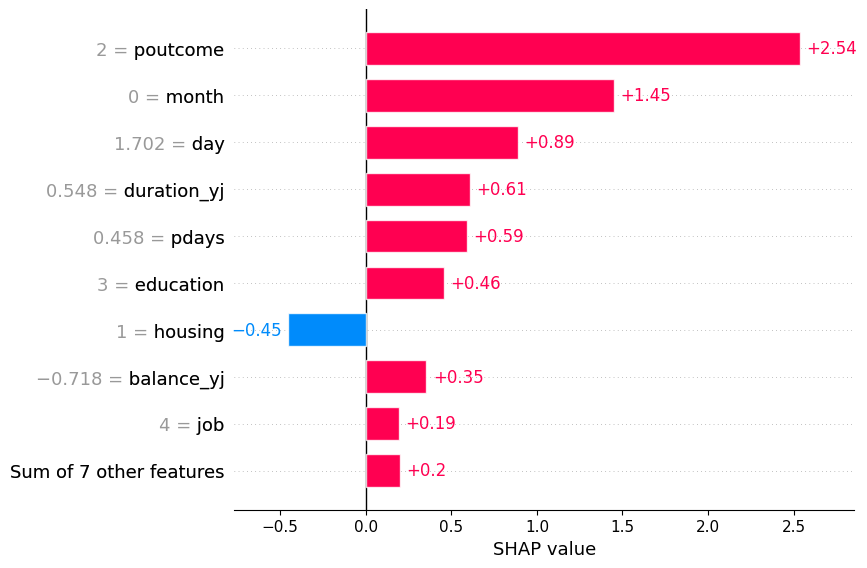


Feature importance bar plot for prediction 3 (index 4951):


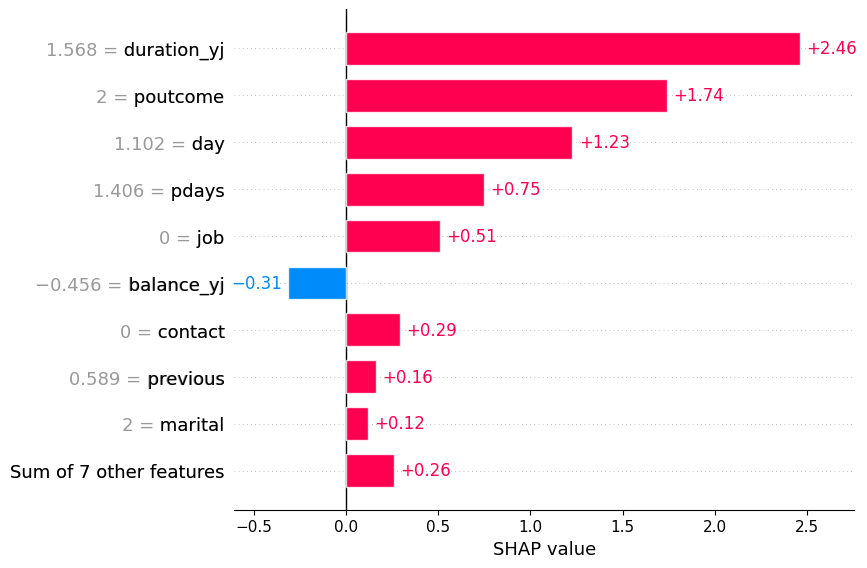


Feature importance bar plot for prediction 4 (index 7422):


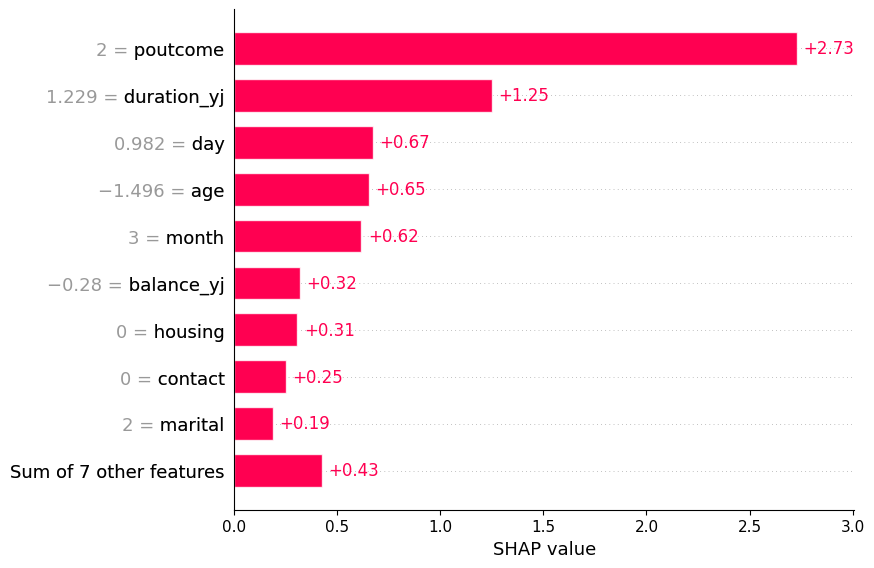


Feature importance bar plot for prediction 5 (index 2399):


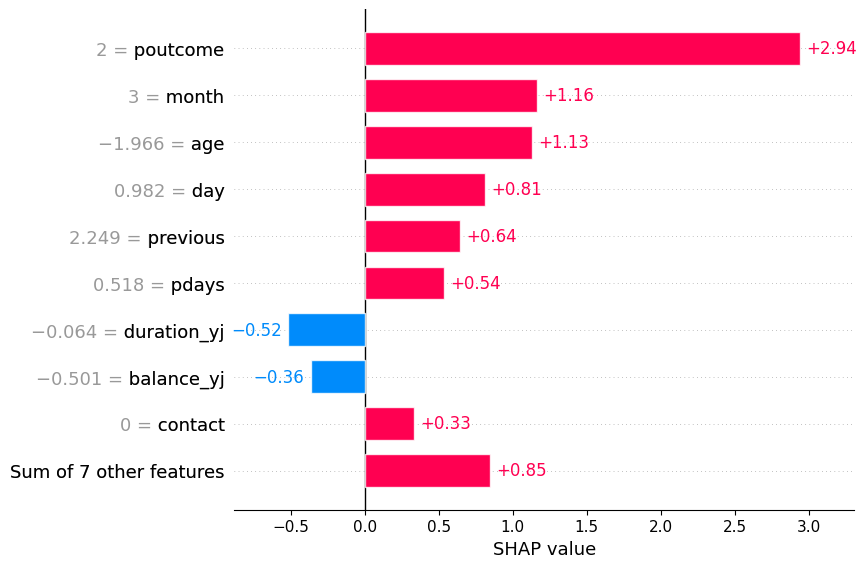

In [68]:
for i, idx in enumerate(top5_indices):
    print(f"\nFeature importance bar plot for prediction {i+1} (index {idx}):")
    
    shap_values_exp = shap.Explanation(
        shap_values_top5[i], 
        feature_names=feature_names,
        data=X_top5[i]
    )
    
    shap.plots.bar(shap_values_exp, max_display=10)

Prediction #1: Driven up by poutcome and long duration; tiny dips from month/job.

Prediction #2: High due to poutcome, month, and day; housing slightly lowers.

Prediction #3: Highest from long duration and poutcome; balance trims a bit.

Prediction #4: High from poutcome and duration; day/age/month add small boosts.

Prediction #5: High from poutcome, month, age, day; duration/balance slightly reduce.




 Decision plot for all 5 predictions together:


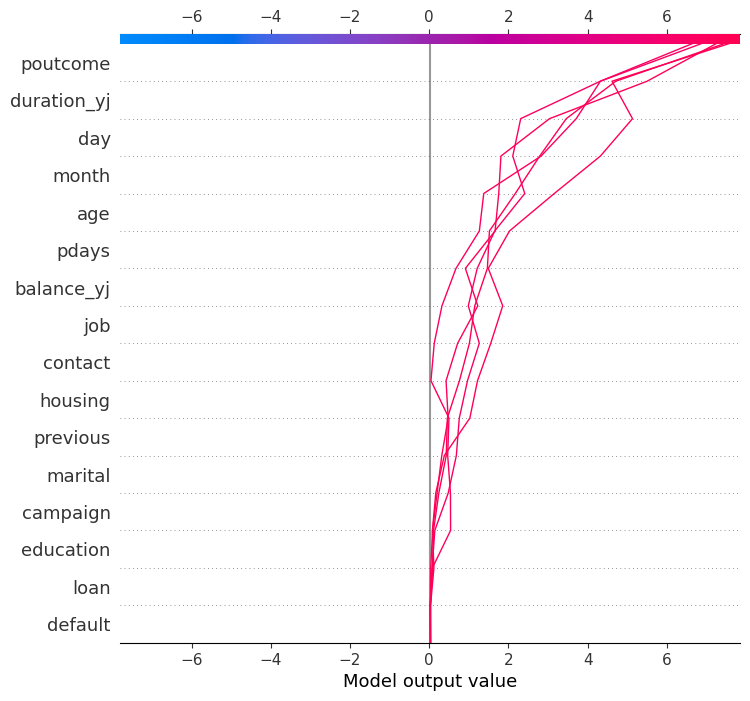

In [65]:
print("\n Decision plot for all 5 predictions together:")
shap.decision_plot(
    explainer.expected_value,
    shap_values_top5,
    X_top5,
    feature_names=feature_names
)

Poutcome is the strongest positive driver followed by duration_yj day month age pdays balance_yj and occasionally housing slightly reduce scores.

## **Conclusion and Key Insights**


- **Best Model**: XGBoost performed best F1 0.60 ROC-AUC 0.92 for predicting term deposit subscriptions.

- **Top Drivers**: poutcome (previous campaign success) is the strongest positive influence, followed by call duration, day, month, age, and previous contacts.

- **Negative Influences**: Balance and sometimes housing slightly reduce subscription chances.

- **Individual Predictions**: SHAP shows each customer’s subscription probability is mostly boosted by positive past outcomes and longer calls.

- **Business Takeaway**: Focus marketing on customers with positive previous outcomes and calls at the right time; use these features to target campaigns smarter and save costs.

- **Overall Insight**: SHAP makes the model transparent and actionable, helping the bank see why customers are likely to subscribe

### **Key Marketing Tips**

1. **Prioritize past positive responders (`poutcome`)** – they’re most likely to subscribe again.
   
2. **Focus on longer calls** – meaningful conversations increase subscription chances.
3. **Target the right days & months** – mid-month & May–August campaigns perform better.
4. **Profile customers carefully** – age and past campaign interactions slightly influence likelihood.
5. **Reduce wasted effort** – avoid campaigns to customers with low balance or poor past outcomes.
